# LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
import pandas as pd

def analyze_feature(df, colonna, quantili=[0.1,0.25,0.50, 0.75,0.9,0.99]):
    serie = df[colonna] 
    
    # CAL values equal to 0
    num_zero = (serie == 0).sum()
    presenza_zero = num_zero > 0
    
    # CAL negative values
    num_negativi = (serie < 0).sum()
    presenza_negativi = num_negativi > 0
    
    # CAL range (min and max)
    valore_min = serie.min()
    valore_max = serie.max()
    range_valori = valore_max - valore_min

     # CAL quantiles
    valori_quantili = serie.quantile(quantili)
    
    # Stampa risultati
    print(f"Analyzed column: {colonna}")
    print(f"Presence of values equal to 0: {presenza_zero}")
    print(f"Number of values equal to 0: {num_zero}")
    print(f"Presence of negative values: {presenza_negativi}")
    print(f"Number of negative values: {num_negativi}")    
    print(f"Minimum value: {valore_min}")
    print(f"Maximum value: {valore_max}")
    print(f"Range (max - min): {range_valori}")

    print(f"\nQuantiles:")
    for q, v in valori_quantili.items():
        print(f"  Q{int(q*100)} ({q}): {v}")

# IMPORT DF

In [3]:
file_path = "../1.DATASET/CMI_NN_V1.csv"
df=pd.read_csv(file_path)
df.head(3)

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-HeartRate,Fitness_Endurance-Max_Stage,FGC-FGC_TL,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,0,5,0,51.0,16.877316,46.0,50.8,NaN,5.0,6.0,...,1.0,19.5413,32.6909,NaN,3.0,2.0,82.152821,4.611111,17.883041,6.5
1,1,9,0,NaN,14.035590,48.0,46.0,70.0,NaN,3.0,...,1.0,15.4107,27.0552,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.0
2,2,10,1,71.0,16.648696,56.5,75.6,94.0,5.0,5.0,...,NaN,NaN,44.9870,54.0,2.0,0.0,82.333333,27.000000,12.450000,10.0


## CALCULATION 

### BMI CALCULATOR

In [4]:
df['Physical-BMI_CAL']=(df['Physical-Weight']/(df['Physical-Height']*df['Physical-Height']))*703

In [5]:
df['Physical-BMI_DELTA']=abs(df['Physical-BMI_CAL']-df['Physical-BMI'])
analyze_feature(df,'Physical-BMI_DELTA')

Analyzed column: Physical-BMI_DELTA
Presence of values equal to 0: True
Number of values equal to 0: 560
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 37.3969886690261
Range (max - min): 37.3969886690261

Quantiles:
  Q10 (0.1): 3.552713678800501e-15
  Q25 (0.25): 2.1178561127044304e-09
  Q50 (0.5): 0.20273417842212282
  Q75 (0.75): 3.8691704648067375
  Q90 (0.9): 7.471754187229403
  Q99 (0.99): 19.78477936690338


### BIA-BIA_TBW CALCULATOR

In [6]:
df["BIA-BIA_TBW_CAL"]=df["BIA-BIA_ECW"]+df["BIA-BIA_ICW"]
df[["BIA-BIA_TBW","BIA-BIA_ECW","BIA-BIA_ICW","BIA-BIA_TBW_CAL"]][(round(df["BIA-BIA_TBW_CAL"],0)==round(df["BIA-BIA_TBW"],0)) & (df["BIA-BIA_TBW_CAL"].notna()) & (df["BIA-BIA_TBW"].notna())]

,BIA-BIA_TBW,BIA-BIA_ECW,BIA-BIA_ICW,BIA-BIA_TBW_CAL
0,32.690900,8.255980,24.434900,32.690880
1,27.055200,6.019930,21.035200,27.055130
3,45.996600,15.592500,30.404100,45.996600
5,63.126500,30.212400,32.914100,63.126500
6,47.221100,16.327500,30.893600,47.221100
...,...,...,...,...
8357,56.124264,25.589103,30.067543,55.656646
8367,37.636891,13.890323,24.472747,38.363069
8422,90.320237,36.123540,53.795521,89.919061
8423,35.712239,14.946110,20.587136,35.533246


In [7]:
df['BIA-BIA_TBW_DELTA']=abs(df['BIA-BIA_TBW_CAL']-df['BIA-BIA_TBW'])
analyze_feature(df,'BIA-BIA_TBW_DELTA')

Analyzed column: BIA-BIA_TBW_DELTA
Presence of values equal to 0: True
Number of values equal to 0: 983
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 4674.379080167579
Range (max - min): 4674.379080167579

Quantiles:
  Q10 (0.1): 0.0
  Q25 (0.25): 7.105427357601002e-15
  Q50 (0.5): 0.3864812666929467
  Q75 (0.75): 5.271583874749137
  Q90 (0.9): 12.22160073939066
  Q99 (0.99): 81.06379660352812


In [8]:
df_tbw_test=(df["BIA-BIA_TBW_CAL"]-df["BIA-BIA_TBW"]).copy()
df_tbw_test.describe()

count    4643.000000
mean        1.128129
std       141.411652
min     -4674.379080
25%        -0.000100
50%         0.000000
75%         3.388651
max      3231.955375
dtype: float64

### BIA-BIA_LST CALCULATOR

In [9]:
df["BIA-BIA_LST_CAL"]=df["BIA-BIA_FFM"] - df["BIA-BIA_BMC"]
df[["BIA-BIA_LST","BIA-BIA_FFM", "BIA-BIA_BMC", "BIA-BIA_LST_CAL"]][(round(df["BIA-BIA_LST_CAL"],0)!=round(df["BIA-BIA_LST"],0)) & (df["BIA-BIA_LST_CAL"].notna()) & (df["BIA-BIA_LST"].notna())]

,BIA-BIA_LST,BIA-BIA_FFM,BIA-BIA_BMC,BIA-BIA_LST_CAL
3960,42.634752,41.410640,3.708782,37.701857
3962,48.520287,50.880564,2.882383,47.998181
3963,70.259368,93.441125,7.037091,86.404034
3964,40.830370,40.192383,5.231689,34.960694
3965,61.924863,63.750798,5.250973,58.499825
...,...,...,...,...
8448,47.333189,44.763927,5.263506,39.500421
8451,88.223778,93.840014,6.682633,87.157381
8454,128.756213,115.712153,7.492883,108.219271
8455,37.154343,42.546078,2.625946,39.920131


In [10]:
df['BIA-BIA_LST_DELTA']=abs(df['BIA-BIA_LST_CAL']-df['BIA-BIA_LST'])
analyze_feature(df,'BIA-BIA_LST_DELTA')

Analyzed column: BIA-BIA_LST_DELTA
Presence of values equal to 0: True
Number of values equal to 0: 138
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 8663.959274598628
Range (max - min): 8663.959274598628

Quantiles:
  Q10 (0.1): 1.0000000003174137e-05
  Q25 (0.25): 3.999999999848569e-05
  Q50 (0.5): 0.37974834714796657
  Q75 (0.75): 4.721665828676446
  Q90 (0.9): 12.319963370349285
  Q99 (0.99): 126.45435294411914


### BIA-BIA_FMI CALCULATOR

In [11]:
df["BIA-BIA_FMI_CAL"]=(df["BIA-BIA_Fat"]/((df["Physical-Height"])*(df["Physical-Height"])))*703
df[["BIA-BIA_FMI","BIA-BIA_FMI_CAL"]][(round(df["BIA-BIA_FMI"],0)!=round(df["BIA-BIA_FMI_CAL"],0))
                                      & (df["BIA-BIA_FMI_CAL"].notna()) & (df["BIA-BIA_FMI"].notna())]


,BIA-BIA_FMI,BIA-BIA_FMI_CAL
18,3.184070,5.547314
26,9.497480,6.258949
49,3.698630,5.492450
59,5.201810,3.280018
60,1.493130,1.523913
...,...,...
8449,3.014520,0.979937
8452,2.547750,2.419222
8456,2.644989,1.707244
8457,5.910016,-43.522459


In [12]:
df['BIA-BIA_FMI_DELTA']=abs(df['BIA-BIA_FMI_CAL']-df['BIA-BIA_FMI'])
analyze_feature(df,'BIA-BIA_FMI_DELTA')

Analyzed column: BIA-BIA_FMI_DELTA
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 2.3507026627248018e-06
Maximum value: 2100.479445665295
Range (max - min): 2100.479443314592

Quantiles:
  Q10 (0.1): 0.0002792460973370936
  Q25 (0.25): 0.0006647838311302223
  Q50 (0.5): 0.4212372222579359
  Q75 (0.75): 1.435551082378935
  Q90 (0.9): 3.3459721247604413
  Q99 (0.99): 18.443830302887694


# CONTROL DATASET

## margin 3 (main one)

In [21]:
df_train_margin3 = df.copy()
df_train_margin3=df_train_margin3[
    (df_train_margin3['Physical-BMI_DELTA']<=0.4)
    #& (df_train_margin3['BIA-BIA_TBW_DELTA']<=0.4)
    #& (df_train_margin3['BIA-BIA_LST_DELTA']<=0.4)
    & (df_train_margin3['BIA-BIA_FMI_DELTA']<=0.4)
    & (df_train_margin3["BIA-BIA_FFM"] < df_train_margin3["Physical-Weight"])
    & (df_train_margin3["BIA-BIA_Fat"] < df_train_margin3["Physical-Weight"])
    #& (df_train_margin3["BIA-BIA_SMM"] < df_train_margin3["BIA-BIA_FFM"]) 
    #& (df_train_margin3['BIA-BIA_BMC']>0) 
    & (df_train_margin3['BIA-BIA_FMI']>0) 
    & (df_train_margin3['BIA-BIA_Fat']>0)   
    & (df_train_margin3['BIA-BIA_LST']< df_train_margin3["Physical-Weight"])  
]
df_train_margin3

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-HeartRate,Fitness_Endurance-Max_Stage,FGC-FGC_TL,...,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,Physical-BMI_CAL,Physical-BMI_DELTA,BIA-BIA_TBW_CAL,BIA-BIA_TBW_DELTA,BIA-BIA_LST_CAL,BIA-BIA_LST_DELTA,BIA-BIA_FMI_CAL,BIA-BIA_FMI_DELTA
0,0,5,0,51.0,16.877316,46.00,50.800000,NaN,5.0,6.0,...,17.883041,6.5,16.877316,1.890399e-11,32.690880,2.000000e-05,38.917650,0.000050,3.061097,0.000333
1,1,9,0,NaN,14.035590,48.00,46.000000,70.0,NaN,3.0,...,18.204545,11.0,14.035590,2.222222e-09,27.055130,7.000000e-05,39.449610,0.000090,1.211592,0.000128
2,2,10,1,71.0,16.648696,56.50,75.600000,94.0,5.0,5.0,...,12.450000,10.0,16.648696,7.721823e-10,NaN,NaN,57.143480,0.147080,3.561984,0.136646
3,3,9,0,71.0,18.292347,56.00,81.600000,97.0,6.0,7.0,...,18.204545,7.0,18.292347,1.224493e-09,45.996600,0.000000e+00,58.933790,0.000010,4.219861,0.000469
5,5,13,1,50.0,22.279952,59.50,112.200000,73.0,5.0,8.0,...,17.200000,10.5,22.279952,7.923191e-10,63.126500,7.105427e-15,79.698140,0.000060,13.497342,0.001458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8173,8173,7,0,61.5,15.214541,50.60,56.600000,83.5,NaN,11.0,...,18.125000,5.5,15.540705,3.261637e-01,32.195916,NaN,44.262294,0.799368,2.665398,0.061707
8203,8203,8,1,77.0,13.685209,48.98,45.700000,82.5,1.5,8.0,...,18.025000,8.5,13.391646,2.935627e-01,30.424102,NaN,NaN,NaN,1.979740,0.041025
8421,8421,9,1,44.5,18.273411,56.84,83.979335,82.5,5.5,8.0,...,18.125000,8.5,18.273411,0.000000e+00,36.455227,4.839158e+00,43.783167,7.077334,2.744327,0.044509
8448,8448,9,0,NaN,16.732175,59.02,82.907818,77.0,NaN,8.0,...,16.025000,8.5,16.732175,3.552714e-15,33.995337,2.201217e+00,39.500421,7.832768,2.319495,0.038384


In [ ]:
df_train_margin3[['id']].to_csv('../1.DATASET/control_id.csv', index=False)

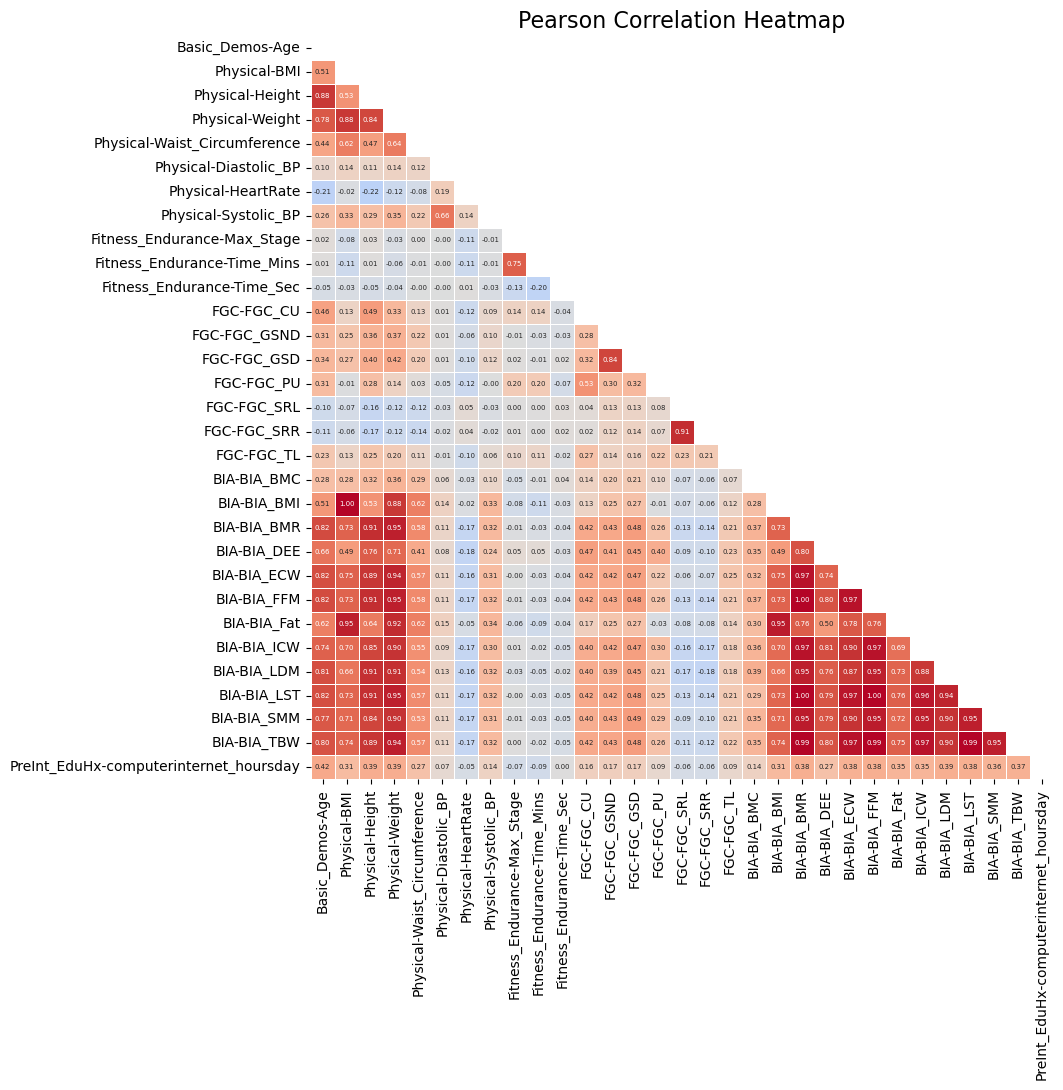

In [ ]:
# column selection
df_corr = df_train_margin3[cols]
 
# Pearson correlation
corr = df_corr.corr(method='pearson')
 
mask = np.triu(np.ones_like(corr, dtype=bool))
 
# heatmap
plt.figure(figsize=(11, 11))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,             
    fmt=".2f",              
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar=False,
    annot_kws={"size": 5},   
    cbar_kws={"shrink": 0.8}
)
 
plt.title("Pearson Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()